# transform data 

In [8]:
import pandas as pd

# 1. Đọc file
df_ddi = pd.read_csv('dataset/KnownDDI.csv')
df_map = pd.read_csv('dataset/mapping.csv')

# 2. Merge dữ liệu (dùng 'left' để giữ lại tất cả dòng dù thiếu mapping)
# Map Drug1
df_final = df_ddi.merge(df_map, left_on='Drug1', right_on='ID', how='left')
df_final.rename(columns={'SMILES': 'Smiles1'}, inplace=True)
df_final.drop('ID', axis=1, inplace=True) # Xóa cột ID thừa

# Map Drug2
df_final = df_final.merge(df_map, left_on='Drug2', right_on='ID', how='left')
df_final.rename(columns={'SMILES': 'Smiles2'}, inplace=True)
df_final.drop('ID', axis=1, inplace=True) # Xóa cột ID thừa

# 3. Tìm và in các ID bị thiếu (có giá trị NaN ở cột SMILES)
missing_ids = set()
missing_ids.update(df_final[df_final['Smiles1'].isna()]['Drug1'].unique())
missing_ids.update(df_final[df_final['Smiles2'].isna()]['Drug2'].unique())

if len(missing_ids) > 0:
    print("--------------------------------------------------")
    print(f"CẢNH BÁO: Có {len(missing_ids)} thuốc chưa có SMILES trong mapping.csv:")
    for mid in missing_ids:
        print(f"- {mid}")
    print("--------------------------------------------------")
else:
    print("Tuyệt vời! Tất cả thuốc đều đã khớp dữ liệu.")

# 4. Lưu file kết quả (bao gồm cả dòng thiếu để bạn dễ check)
# Chỉ giữ lại các cột cần thiết
output_df = df_final[['Smiles1', 'Smiles2', 'Label']]
output_df.to_csv('SMILES_DDI.csv', index=False)

print("Đã lưu file kết quả: SMILES_DDI.csv")

--------------------------------------------------
CẢNH BÁO: Có 141 thuốc chưa có SMILES trong mapping.csv:
- DB09244
- DB01423
- DB08996
- DB02709
- DB09204
- DB01034
- DB13450
- DB09018
- DB08993
- DB09211
- DB08800
- DB09198
- DB07615
- DB09014
- DB09232
- DB08957
- DB13025
- DB09290
- DB09323
- DB01511
- DB06263
- DB08796
- DB01466
- DB09223
- DB01422
- DB08802
- DB09231
- DB01252
- DB01463
- DB04786
- DB01356
- DB09008
- DB09215
- DB09273
- DB01578
- DB00375
- DB06219
- DB08922
- DB00104
- DB00954
- DB11268
- DB00460
- DB01615
- DB01397
- DB09279
- DB09235
- DB00837
- DB08954
- DB01545
- DB09224
- DB09218
- DB08795
- DB00453
- DB08869
- DB04894
- DB08994
- DB01207
- DB08970
- DB09017
- DB01355
- DB09262
- DB08991
- DB01431
- DB00803
- DB11106
- DB01295
- DB09285
- DB02187
- DB09245
- DB01567
- DB09016
- DB08811
- DB06737
- DB08806
- DB09230
- DB00764
- DB01412
- DB09021
- DB08974
- DB09227
- DB08798
- DB00866
- DB09396
- DB01685
- DB01878
- DB06264
- DB01384
- DB00232
- DB09265
- 

In [ ]:
import pandas as pd
import requests
import time

def get_smiles_pubchem(drugbank_id):
    """
    Gọi API PubChem để lấy Canonical SMILES dựa trên mã DrugBank (DBxxxxx).
    API Endpoint: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/...
    """
    # PubChem cho phép search bằng tên khác (Synonym), ta truyền mã DB vào đây
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{drugbank_id}/property/CanonicalSMILES/TXT"
    
    try:
        # Timeout 10s để tránh treo nếu mạng lag
        response = requests.get(url, timeout=10)
        
        # 200 OK -> Có dữ liệu
        if response.status_code == 200:
            return response.text.strip()
        
    except Exception as e:
        print(f"Error fetching {drugbank_id}: {e}")
    
    return None

# --- BẮT ĐẦU XỬ LÝ ---

# 1. Load dữ liệu
print("Đang đọc file...")
df_ddi = pd.read_csv('dataset/KnownDDI.csv')
df_map = pd.read_csv('dataset/mapping.csv')

# 2. Xác định các ID bị thiếu
all_ids = set(df_ddi['Drug1']).union(set(df_ddi['Drug2']))
current_map_ids = set(df_map['ID'])
missing_ids = list(all_ids - current_map_ids)

print(f"Tổng số thuốc cần tìm SMILES: {len(missing_ids)}")

# 3. Query PubChem cho các ID thiếu
new_mappings = []

if len(missing_ids) > 0:
    print("Bắt đầu lấy dữ liệu từ PubChem...")
    
    for i, db_id in enumerate(missing_ids):
        smiles = get_smiles_pubchem(db_id)
        
        if smiles:
            print(f"[{i+1}/{len(missing_ids)}] {db_id}: OK")
            new_mappings.append({'ID': db_id, 'SMILES': smiles})
        else:
            print(f"[{i+1}/{len(missing_ids)}] {db_id}: Not Found (Có thể là thuốc sinh học)")
        
        time.sleep(0.2)

    # 4. Cập nhật vào file mapping.csv ngay lập tức
    if new_mappings:
        df_new = pd.DataFrame(new_mappings)
        df_map = pd.concat([df_map, df_new], ignore_index=True)
        df_map.to_csv('mapping.csv', index=False)
        print(f"\nĐã cập nhật thêm {len(new_mappings)} thuốc vào mapping.csv")
    else:
        print("\nKhông tìm thấy thêm thuốc nào mới trên PubChem.")
else:
    print("Dữ liệu đã đầy đủ, không có ID nào bị thiếu.")

# 5. Merge tạo file cuối cùng (SMILES_DDI.csv)
print("\nĐang tạo file kết quả SMILES_DDI.csv...")

# Map Drug1
df_final = df_ddi.merge(df_map, left_on='Drug1', right_on='ID', how='left')
df_final.rename(columns={'SMILES': 'Smiles1'}, inplace=True)
df_final.drop(columns=['ID'], inplace=True)

# Map Drug2
df_final = df_final.merge(df_map, left_on='Drug2', right_on='ID', how='left')
df_final.rename(columns={'SMILES': 'Smiles2'}, inplace=True)
df_final.drop(columns=['ID'], inplace=True)

# Lọc bỏ các dòng vẫn bị NaN (do PubChem cũng không tìm thấy)
df_clean = df_final.dropna(subset=['Smiles1', 'Smiles2'])

# Lưu file
df_clean[['Smiles1', 'Smiles2', 'Label']].to_csv('SMILES_DDI.csv', index=False)

print(f"HOÀN TẤT! File 'SMILES_DDI.csv' có {len(df_clean)} dòng dữ liệu sạch.")
print(f"Đã loại bỏ {len(df_final) - len(df_clean)} dòng do không tìm thấy cấu trúc hóa học.")

Đang đọc file...
Tổng số thuốc cần tìm SMILES: 141
Bắt đầu lấy dữ liệu từ PubChem...
[1/141] DB09244: OK
[2/141] DB01423: OK
[3/141] DB08996: OK
[4/141] DB02709: OK
[5/141] DB09204: OK
[6/141] DB08993: OK
[7/141] DB09018: OK
[8/141] DB01034: OK
[9/141] DB13450: OK
[10/141] DB09211: OK
[11/141] DB08800: OK
[12/141] DB09198: OK
[13/141] DB07615: OK
[14/141] DB09014: OK
[15/141] DB09232: OK
[16/141] DB08957: OK
[17/141] DB13025: OK
[18/141] DB09290: OK
[19/141] DB09323: OK
[20/141] DB01511: OK
[21/141] DB06263: OK
[22/141] DB08796: OK
[23/141] DB01466: OK
[24/141] DB09223: OK
[25/141] DB01422: OK
[26/141] DB08802: OK
[27/141] DB09231: OK
[28/141] DB01252: OK
[29/141] DB01463: OK
[30/141] DB04786: OK
[31/141] DB01356: OK
[32/141] DB09008: OK
[33/141] DB09215: OK
[34/141] DB09273: OK
[35/141] DB01578: OK
[36/141] DB00375: Not Found (Có thể là thuốc sinh học)
[37/141] DB06219: Not Found (Có thể là thuốc sinh học)
[38/141] DB08922: OK
[39/141] DB00104: OK
[40/141] DB00954: OK
[41/141] DB00460

/var/folders/68/k7gdvy9j4qs0964qr5hv4l2h0000gn/T/ipykernel_13069/3865373395.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Label', data=df, palette='viridis')


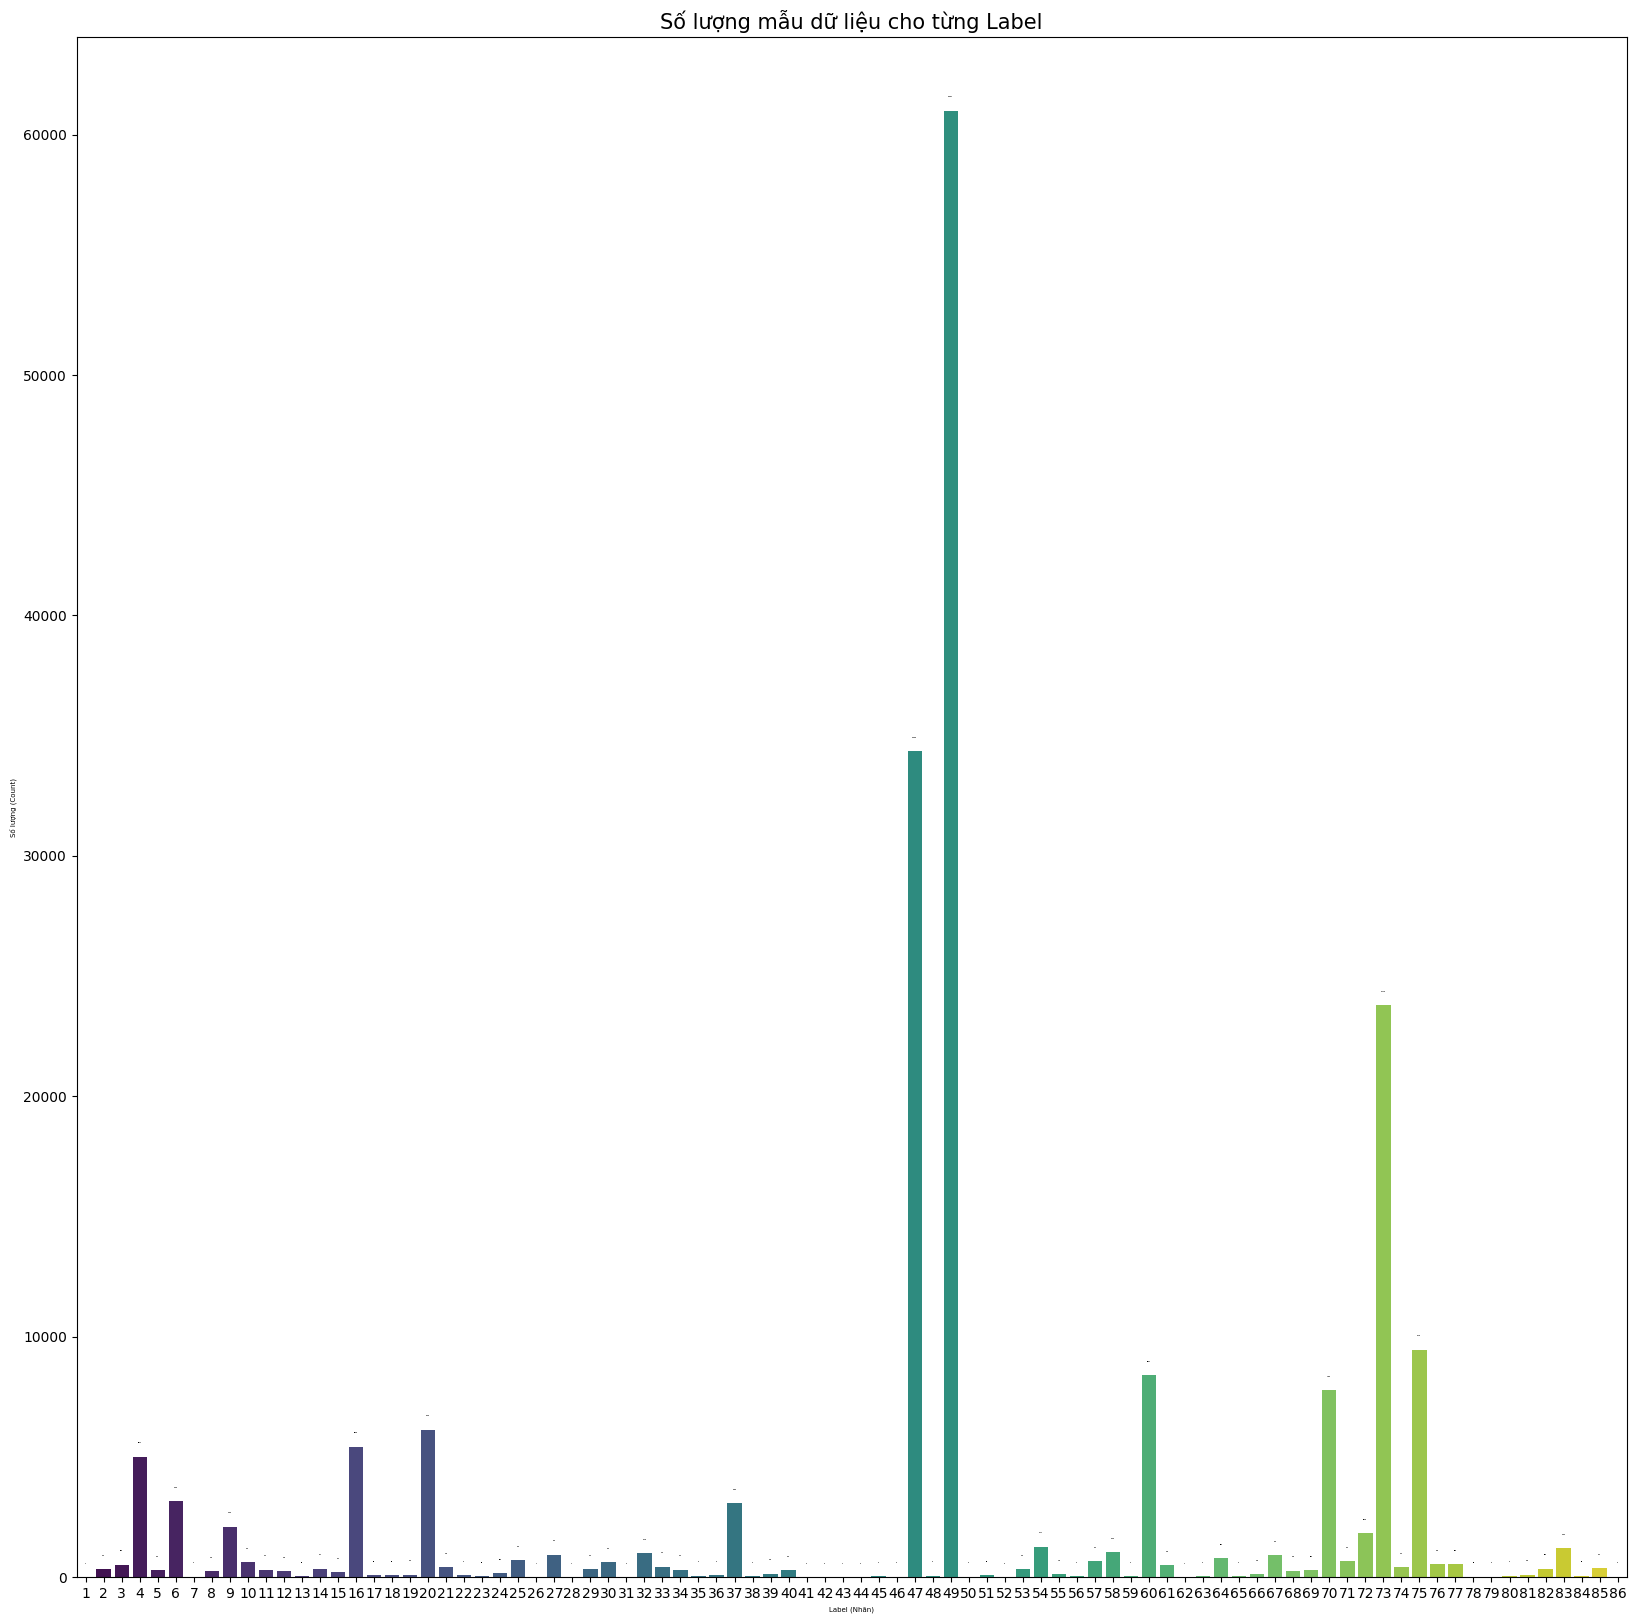

Thống kê chi tiết:
Label
49    60997
47    34360
73    23779
75     9470
60     8397
      ...  
28       11
1        11
52       10
26        7
42        6
Name: count, Length: 86, dtype: int64


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu (Thay 'du_lieu_cua_ban.csv' bằng tên file thực tế của bạn)
# Nếu file là Excel, hãy dùng pd.read_excel('ten_file.xlsx')
df = pd.read_csv('SMILES_DDI.csv')

# 2. Thiết lập kích thước biểu đồ
plt.figure(figsize=(20, 20))

# 3. Vẽ biểu đồ đếm số lượng (Count Plot)
# Cột 'Label' là cột chứa nhãn 1, 2... như trong ảnh
ax = sns.countplot(x='Label', data=df, palette='viridis')

# 4. Thêm số lượng cụ thể lên trên đỉnh mỗi cột (để dễ đọc)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=1, fontweight='bold')

# 5. Tinh chỉnh tiêu đề và nhãn
plt.title('Số lượng mẫu dữ liệu cho từng Label', fontsize=15)
plt.xlabel('Label (Nhãn)', fontsize=5)
plt.ylabel('Số lượng (Count)', fontsize=5)

# 6. Hiển thị
plt.show()

# --- Kiểm tra nhanh bằng số liệu ---
print("Thống kê chi tiết:")
print(df['Label'].value_counts())

In [18]:
import pandas as pd

# Đọc file CSV
df = pd.read_csv('SMILES_DDI.csv')

# Đếm số lượng mỗi label
counts = df['Label'].value_counts()

# Lọc ra các label có số lượng bằng với số lượng nhỏ nhất
min_labels = counts[counts == counts.min()]

print(f"Số lượng xuất hiện ít nhất là: {counts.min()}")
print("Các label xuất hiện ít nhất:", min_labels.index.tolist())

Số lượng xuất hiện ít nhất là: 6
Các label xuất hiện ít nhất: [42]


In [28]:
import pandas as pd

df = pd.read_csv('SMILES_DDI.csv')

# 1. Đếm tần suất tất cả các thuốc trong cả 2 cột
all_smiles = pd.concat([df['Smiles1'], df['Smiles2']])
counts = all_smiles.value_counts()

# 2. Lấy danh sách thuốc xuất hiện dưới 5 lần
rare_drugs = counts[counts < 5].index

# 3. Lọc bỏ các dòng có chứa thuốc hiếm (ở cột 1 hoặc cột 2)
# Dùng ~ để lấy phần ngược lại (giữ lại dòng KHÔNG chứa thuốc hiếm)
mask = df['Smiles1'].isin(rare_drugs) | df['Smiles2'].isin(rare_drugs)
df_filtered = df[~mask]

# Lưu và in kết quả
df_filtered.to_csv('SMILES_DDI_filtered.csv', index=False)
print(f"Đã loại bỏ {len(df) - len(df_filtered)} dòng.")
print(f"Số dòng còn lại: {len(df_filtered)}")

Đã loại bỏ 240 dòng.
Số dòng còn lại: 191842


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Đọc file (bạn đổi tên file nếu dùng file đã lọc bước trước)
df = pd.read_csv('SMILES_DDI_filtered.csv')

# Chia train/test với stratify theo cột Label
# random_state=42 giúp kết quả cố định mỗi lần chạy
train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['Label'], 
    random_state=42
)

# Lưu ra 2 file riêng biệt
train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)

print(f"Đã chia xong. Train: {len(train_df)} dòng, Test: {len(test_df)} dòng.")

Đã chia xong. Train: 153473 dòng, Test: 38369 dòng.
